# D2: growing velocity, bounded energy
The main message: shrinking volume can outweigh growing speed squared.
This notebook evaluates three explicit toy models and the paper's core scaling.
It does not reconstruct the proposed solution or solve Navier-Stokes.
All physical scales are in consistent arbitrary units; h=0 is a limiting case.
See ../../writing/d2_finite_energy/source-notes.md for the audited definitions.

In [1]:
from pathlib import Path
import json
import numpy as np
import sympy as sp
from IPython.display import display, Markdown, Image
from nscomp.energy import (CoreEnergyScaling, narrow_gaussian_squared_integral,
    cylindrical_energy_quadrature, gaussian_energy_tail_fraction, material_map)
from nscomp.d2 import load_parameters, reference_model, generate, ratio_table, WRITING
p = load_parameters()
model = reference_model(p)
summary = generate()
print(json.dumps(summary, indent=2))

{
  "h_baseline": 0.0,
  "baseline_is_limiting_toy": true,
  "radial_exponent": 0.5,
  "axial_exponent": 0.5,
  "speed_exponent": -0.5,
  "volume_exponent": 1.5,
  "energy_exponent": 0.5,
  "gaussian_energy_constant": 15.136284808687387,
  "gaussian_reference_energy": 15.136284808687387,
  "ratios_at_time_ratio_1e_6": {
    "radial": 0.001,
    "axial": 0.001,
    "speed": 1000.0,
    "volume": 9.999999999999999e-10,
    "energy": 0.001,
    "slenderness": 1.0
  },
  "max_order64_relative_quadrature_error": 3.3306690738754696e-15,
  "quadrature_tail_fraction": 1.0435995085739128e-26,
  "necessary_ceiling_slenderness_ratio_at_1e_12": 0.998746340071075,
  "paper_profile_evaluated": false,
  "total_paper_energy_evaluated": false,
  "parameters_sha256": "c2cb53c0ffda5259951f1bbad1d045d605db1814c1294133f1ed6e8ed631af36"
}


## 1. A squared integral can stay bounded while a peak diverges
For $f_\epsilon(x)=\epsilon^{-p}\exp[-x^2/(2\epsilon^2)]$,
$\int f_\epsilon^2 dx=\sqrt\pi\epsilon^{1-2p}$.
Try changing p. Positive values below, at, and above 1/2 give three different outcomes.

p=0.25: peak at width 1e-6 = 31.6228; squared integral = 0.00177245
p=0.5: peak at width 1e-6 = 1000; squared integral = 1.77245
p=0.75: peak at width 1e-6 = 31622.8; squared integral = 1772.45


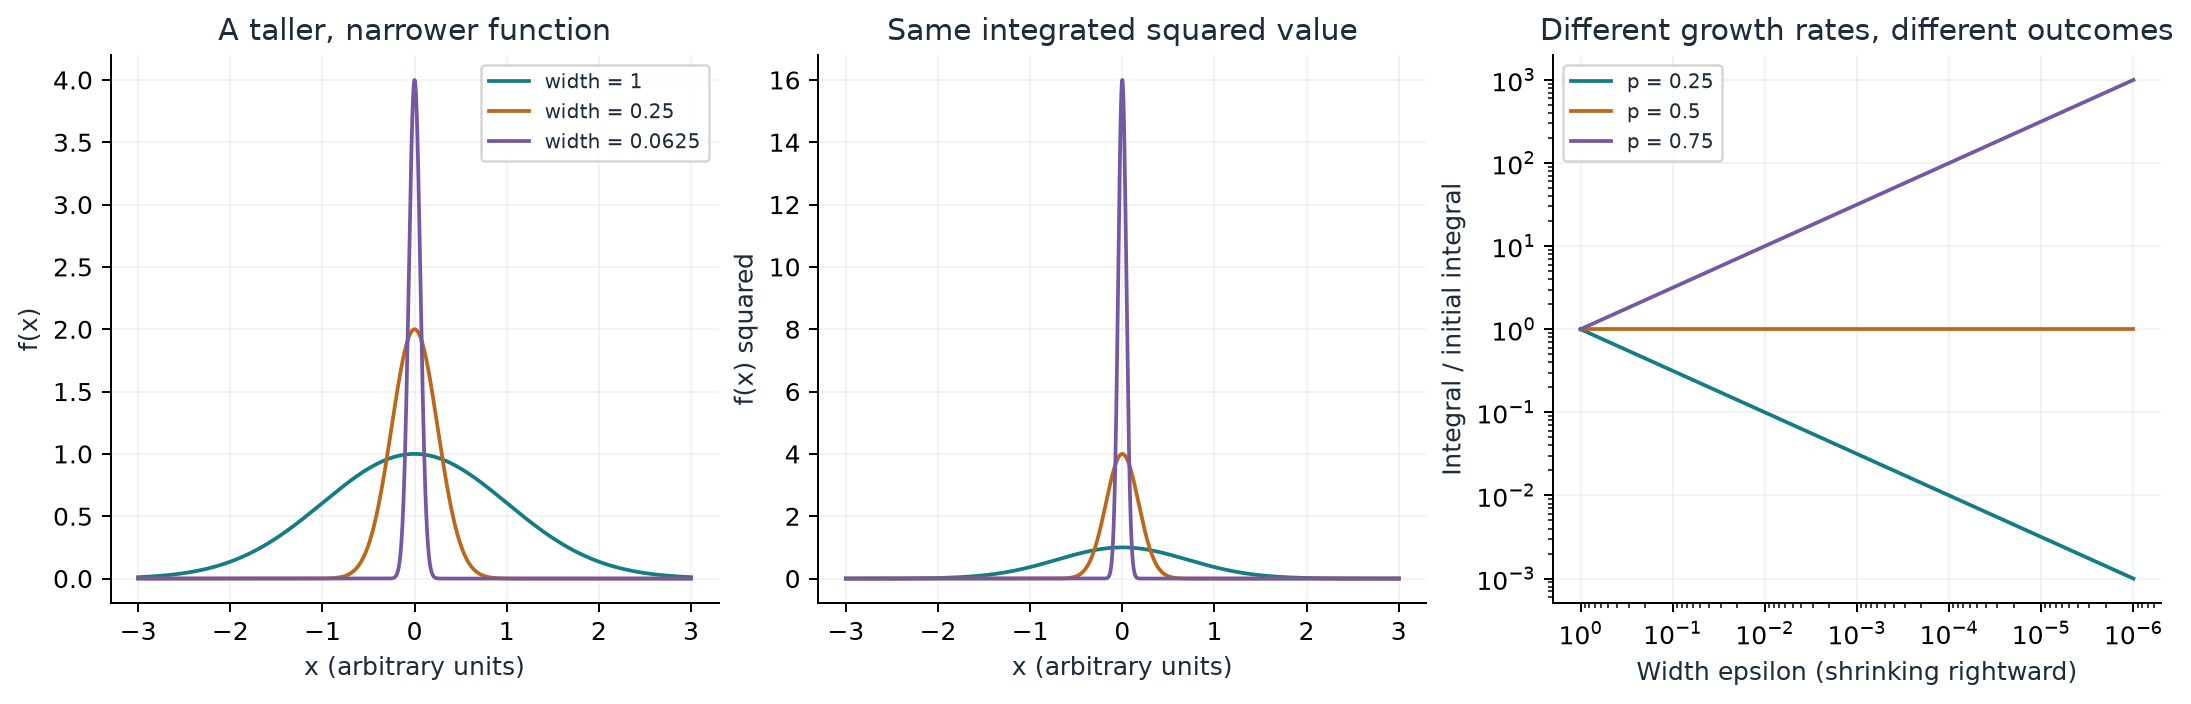

In [2]:
for exponent in (0.25, 0.5, 0.75):
    print(f"p={exponent}: peak at width 1e-6 = {1e-6**(-exponent):.6g}; squared integral = {narrow_gaussian_squared_integral(1e-6, exponent):.6g}")
display(Image(filename=str(WRITING/'figures/01_tall_and_narrow.png')))

## 2. Eliminate the cylindrical volume factors
$r=aR$, $z=bZ$ gives $dV=a^2bR\,dR\,d\theta\,dZ$.
With the paper's powers the dominant core energy is proportional to $s^{1/2-3h}$,
where $s=\tau/\tau_0$. The radial component is no larger than order $s^{1/2-h}$.

Volume: s**(3/2 - h) Energy: s**(1/2 - 3*h)


| Time remaining / reference | Speed / reference | Radius / reference | Axial width / reference | Volume / reference | Energy / reference |
| --- | --- | --- | --- | --- | --- |
| 1 | 1 | 1 | 1 | 1 | 1 |
| 0.01 | 10 | 0.1 | 0.1 | 0.001 | 0.1 |
| 0.0001 | 100 | 0.01 | 0.01 | 1e-06 | 0.01 |
| 1e-06 | 1e+03 | 0.001 | 0.001 | 1e-09 | 0.001 |

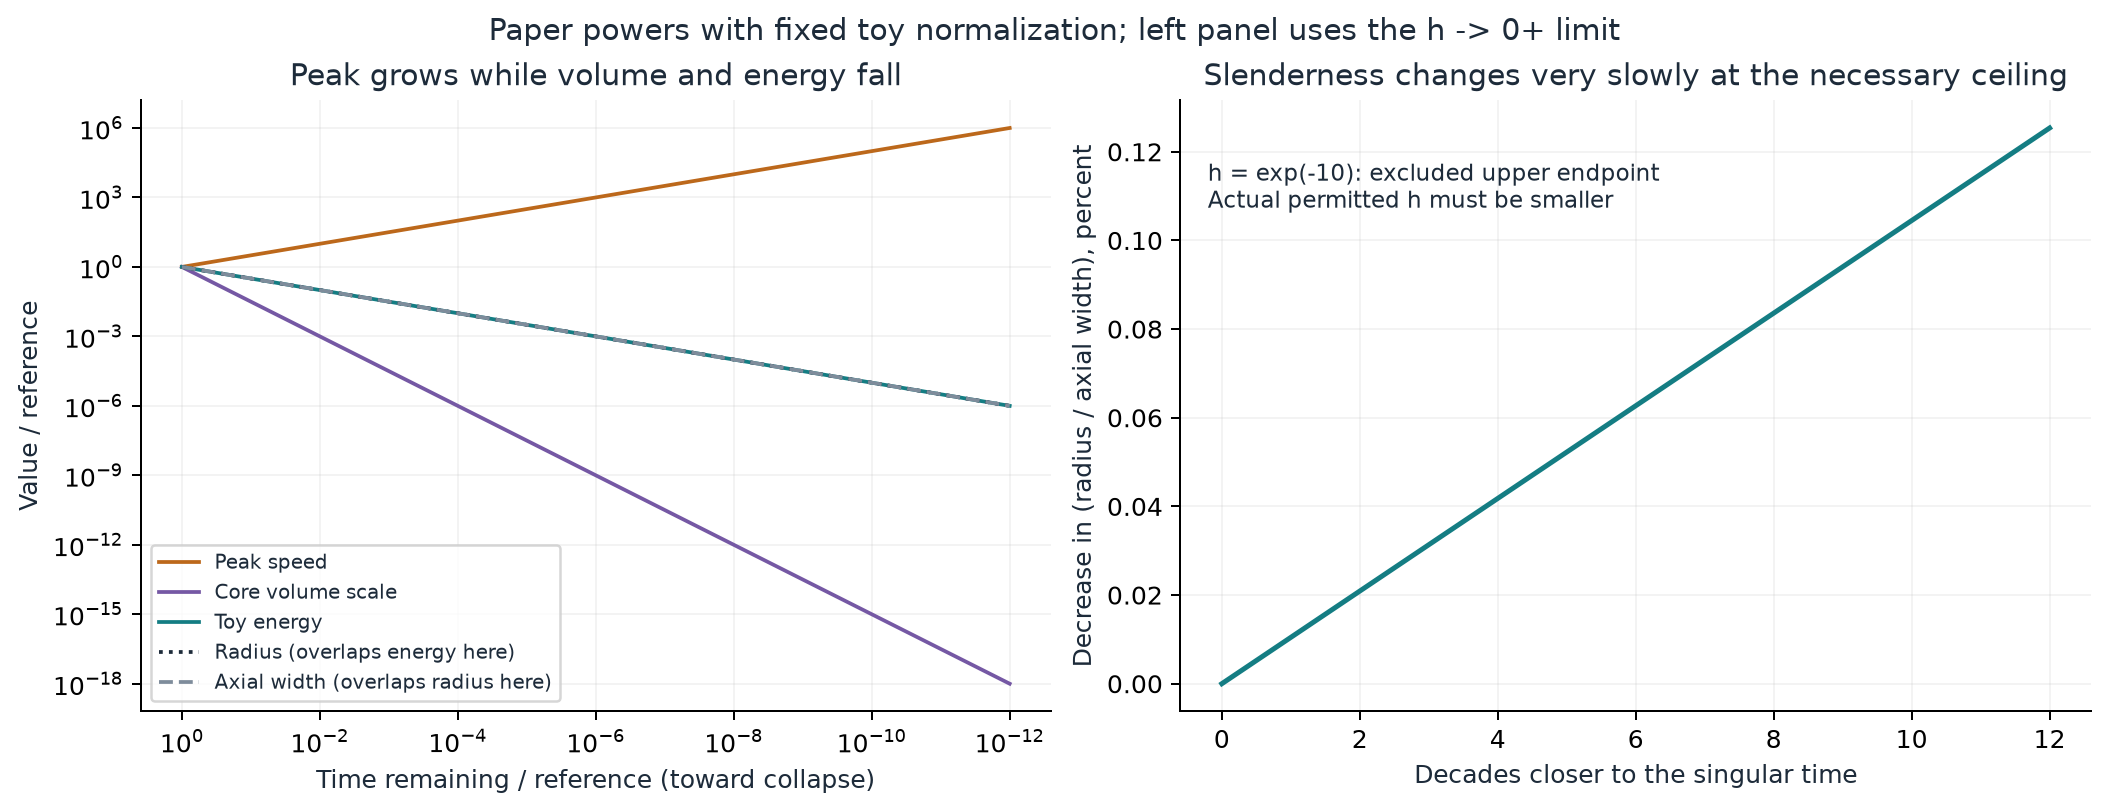

In [3]:
s, h = sp.symbols("s h", positive=True)
volume = s**sp.Rational(1,2)*s**sp.Rational(1,2)*s**(sp.Rational(1,2)-h)
energy = sp.simplify(volume*s**(-1-2*h))
print("Volume:", sp.simplify(volume), "Energy:", energy)
display(Markdown(ratio_table(p)))
display(Image(filename=str(WRITING/'figures/02_core_scaling.png')))

## 3. Integrate a smooth divergence-free Gaussian swirl
$u_\theta=U R\exp[(1-R^2-Z^2)/2]$, with radial and axial velocity zero.
The exact whole-space energy is $\rho e\pi^{3/2}U^2a^2b/2$.
This is the whole energy of the toy, not the whole energy of the paper's flow.
Quadrature uses 0<=r<=8a and |z|<=8b; the tail is estimated separately.

In [4]:
rows = []
for order in p["quadrature"]["orders"]:
    numeric = cylindrical_energy_quadrature(model, 1e-4, order)
    exact = float(model.toy_energy(1e-4))
    rows.append((order, numeric, abs(numeric/exact-1)))
print("order, numeric energy, relative error")
for row in rows:
    print(row)
print("Exact omitted energy fraction:", gaussian_energy_tail_fraction(8))
assert rows[-2][2] < 2e-12

order, numeric energy, relative error
(16, 0.1468197628851204, 0.030014533019000922)
(32, 0.15136279062877236, 3.7960505006040535e-07)
(48, 0.15136284808687003, 2.55351295663786e-14)
(64, 0.15136284808687436, 3.1086244689504383e-15)
(96, 0.1513628480868751, 7.993605777301127e-15)
Exact omitted energy fraction: 1.0435995085739128e-26


## 4. Change the normalization or the exponent
Changing a0, b0, or u0 changes the absolute toy energy. Changing h changes its time exponent.
The class accepts larger h for mathematical examples; such values are not paper parameters.
The h=0.2 example below deliberately lies outside the paper's range and has diverging energy.

In [5]:
for chosen_h in (0, 1e-6, 0.1, 1/6, 0.2):
    alternate = CoreEnergyScaling(h=chosen_h, a0=2, b0=3, u0=4)
    print(f"h={chosen_h:.7g}, energy exponent={alternate.energy_exponent:.7g}, energy ratio at s=1e-6={alternate.ratios(1e-6)['energy']:.7g}")

h=0, energy exponent=0.5, energy ratio at s=1e-6=0.001
h=1e-06, energy exponent=0.499997, energy ratio at s=1e-6=0.001000041
h=0.1, energy exponent=0.2, energy ratio at s=1e-6=0.06309573
h=0.1666667, energy exponent=0, energy ratio at s=1e-6=1
h=0.2, energy exponent=-0.1, energy ratio at s=1e-6=3.981072


## 5. A material parcel preserves its volume
For the separate affine field $v=(-x/(2\tau),-y/(2\tau),z/\tau)$,
the exact material map has factors $(\sqrt s,\sqrt s,1/s)$.
It has determinant one. The affine field has infinite whole-space energy and serves only this geometry example.

s= 1 points= [[1.0, 0.0, 1.0], [0.0, 1.0, -1.0]] volume factor= 1.0
s= 0.1 points= [[0.31622776601683794, 0.0, 10.0], [0.0, 0.31622776601683794, -10.0]] volume factor= 1.0000000000000004
s= 0.01 points= [[0.1, 0.0, 100.0], [0.0, 0.1, -100.0]] volume factor= 1.0000000000000009


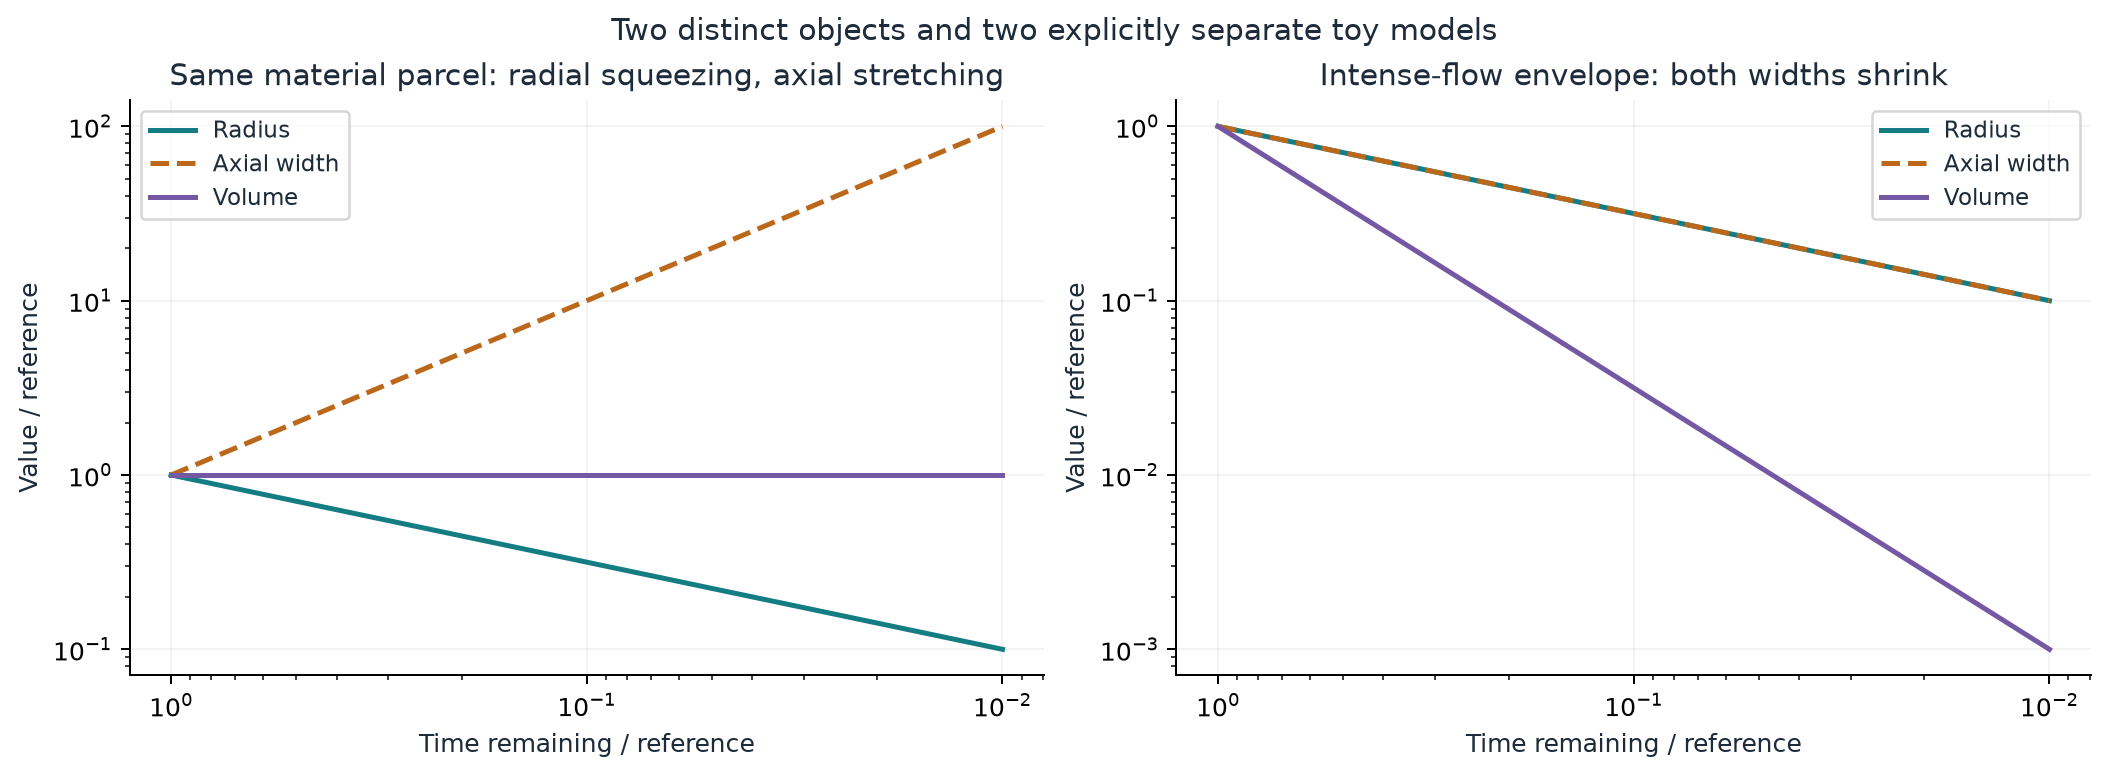

In [6]:
points = np.array([[1., 0., 1.], [0., 1., -1.]])
for s_value in (1, 0.1, 0.01):
    print("s=", s_value, "points=", material_map(points, s_value).tolist(),
          "volume factor=", np.linalg.det(material_map(np.eye(3), s_value)))
display(Image(filename=str(WRITING/'figures/03_material_and_core.png')))

## 6. Animation and interpretation
Open ../../writing/d2_finite_energy/animations/core_collapse.html for play/pause and a frame slider.
The left image uses fixed spatial coordinates and a fixed logarithmic speed scale.
The right uses current similarity coordinates and speed divided by its current peak.
No particle paths are shown. Movie time is uniform in log(time remaining).
The static image below is the endpoint s=0.01, not the singular time.

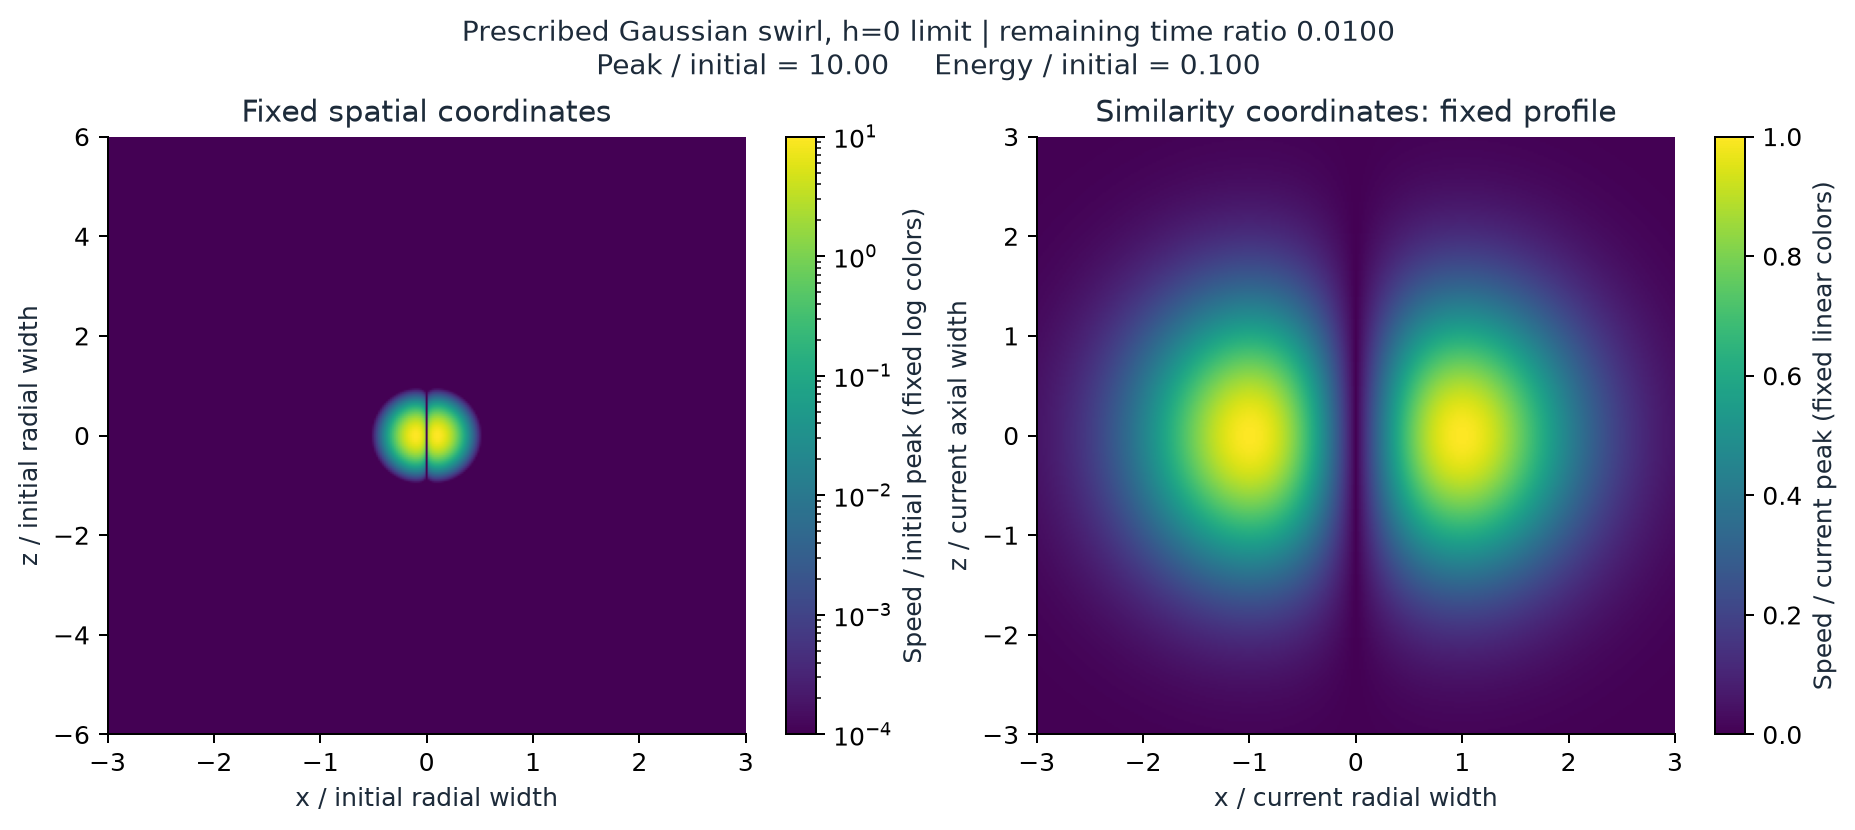

Animation: C:\Pardeep\trunk\navier-stokes-problem\writing\d2_finite_energy\animations\core_collapse.html


In [7]:
display(Image(filename=str(WRITING/'figures/04_animation_static.png')))
print("Animation:", WRITING/'animations/core_collapse.html')

## What was checked
Independent Cartesian/cylindrical quadratures, symbolic volume and energy exponents,
Gaussian regularity and divergence, and the exact material-map determinant are covered by code/tests/test_energy.py.
A finite computation checks the formulas at sampled times; the displayed power laws determine their limiting behavior.
The total paper energy, correction fields, forcing, and physical calibration have not been evaluated.